In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

In [2]:
SEED = 42
np.random.seed(SEED) # pentru a ne asigura ca numerele generate vor fi tot aceleasi

# Prima cerinta - implementarea mediului CliffWalkingEnv

In [38]:
class CliffWalkingEnv:
    """
    In cadrul problemei avem o grila de 4x12
    Coordonate: (linie, coloana),
    (0,0) = stanga-sus.
    Start: (3,0)
    Goal: (3,11)
    Cliff: (3,1)…(3,10)
    Acțiuni: 0=UP, 1=DOWN, 2=LEFT, 3=RIGHT
    Recompense: -1 pas normal | -100 cliff (teleportare inapoi la Start) | 0 Goal
    γ = 1.0
    """
    ROWS   = 4
    COLS   = 12
    START  = (3, 0)
    GOAL   = (3, 11)
    CLIFF  = [(3, c) for c in range(1, 11)]

    # Acțiuni posibile
    ACTIONS = {
        0: (-1,  0),   # UP
        1: ( 1,  0),   # DOWN
        2: ( 0, -1),   # LEFT
        3: ( 0,  1),   # RIGHT
    }

    ACTION_SYMBOLS = {0: '↑', 1: '↓', 2: '←', 3: '→'}
    N_STATES  = ROWS * COLS   # 48
    N_ACTIONS = 4

    def __init__(self):
        self.state = None
        self.reset()

    def _rc_to_s(self, r, c):
        """ Transforma din doua coordonate intr-un singur scalar """
        return r * self.COLS + c

    def _s_to_rc(self, s):
        """ Transforma dintr-un scalar in doua coordonate """
        return divmod(s, self.COLS)

    def reset(self) -> int:
        """ Pune agentul inapoi la pozitia de start """
        self.state = self._rc_to_s(*self.START)
        return self.state

    def step(self, action: int):
        """
        Functia pe care agentul o apeleaza cand vrea sa faca o miscare.
        Ea returnează trei lucruri:
        -> unde a ajuns
        -> ce recompensă a primit
        -> dacă s-a terminat jocul.
        """
        r, c = self._s_to_rc(self.state)
        dr, dc = self.ACTIONS[action]

        # Calculeaza noua pozitie
        nr = max(0, min(self.ROWS - 1, r + dr))
        nc = max(0, min(self.COLS - 1, c + dc))

        # Verificarea prapastiei Cliff
        # Daca noua pozitie e in prapastie se primeste penalizarea de -100 de puncte si punctul curent este teleportat din nou la start,
        # dar jocul nu s-a terminat deoarece trebuie sa invatam cum iesim de acolo
        if (nr, nc) in self.CLIFF:
            self.state = self._rc_to_s(*self.START)
            return self.state, -100, False

        # Daca s-a ajuns la pozitia de final primeste recompensa 0 si jocul se termina
        if (nr, nc) == self.GOAL:
            self.state = self._rc_to_s(*self.GOAL)
            return self.state, 0, True

        # Pas normal - daca nu suntem nici in prapastie, dar nici la final de joc se ia taxa de drum (-1) si continua mersul
        self.state = self._rc_to_s(nr, nc)
        return self.state, -1, False

    def render(self, Q=None, title=""):
        """
        Functia de vizualizare care deseneaza in consola (folosind litere si simboluri) unde se află agentul (A), unde e prapastia (X) si unde e tinta (G).
        """
        r_agent, c_agent = self._s_to_rc(self.state)
        print(f"\n{'='*36} {title}")
        for r in range(self.ROWS):
            row_str = ""
            for c in range(self.COLS):
                if (r, c) == self.START:
                    ch = 'S'
                elif (r, c) == self.GOAL:
                    ch = 'G'
                elif (r, c) in self.CLIFF:
                    ch = 'X'
                elif Q is not None:
                    s = self._rc_to_s(r, c)
                    ch = self.ACTION_SYMBOLS[int(np.argmax(Q[s]))]
                else:
                    ch = '·'
                if (r, c) == self._s_to_rc(self.state):
                    ch = 'A'   # poziția curentă a agentului
                row_str += ch + ' '
            print(' ' + row_str)
        print()

# Implementarea Q-Learning si Sarsa

In [ ]:
# Q-Learning - vede drumul cel mai scurt, exact pe marginea prăpastiei. Cauta in marea majoritate drumul cel mai eficient, dar avand in vedere ca el exploreaza, uneori
# mai face pasi la intamplare si astfel cade foarte des in prapastie in timpul invatarii. El ignora acest risc in calculele sale finale, crezand ca la sfarsit va avea
# rezultatul perfect

# SARSA - observa ca uneori din cauza eplorarii mai face greseli si prefera sa fie prudent si sa ocoleasca, pe randul de sus, deoarece daca face acolo o greseala nu cade
# in groapa si penalitatea nu e atat de mare (-100 in cazul gropilor)

# Cerinta 2 - QLearning si Sarsa (from Scratch)

In [ ]:
# Modul in care agentul invata din greseli

In [39]:
def epsilon_greedy(Q, state, epsilon, n_actions):
    """
    Functia care defineste cum alege agentul miscarea
    Mecanismul prin care balansăm explorarea (descoperirea de drumuri noi) cu exploatarea (folosirea drumului deja cunoscut)
    """
    if np.random.random() < epsilon:
        return np.random.randint(n_actions) # explorare
    return int(np.argmax(Q[state])) # exploatare

In [40]:
def run_q_learning(env, n_episodes=500, alpha=0.1, gamma=1.0, epsilon=0.1):
    # Q-Learning este un algoritm off-policy, iar asta inseamna ca el invata despre politica optima,
    # ignorand faptul că el insusi mai face greseli (pasi random).
    # Update: Q(s,a) ← Q(s,a) + α·[r + γ·max_a' Q(s',a') − Q(s,a)]

    Q = np.zeros((env.N_STATES, env.N_ACTIONS)) # se creeaza matricea de 48x4
    episode_rewards = []

    for ep in range(n_episodes):
        s = env.reset() # resetam la start
        total_reward = 0
        done = False

        while not done:
            a = epsilon_greedy(Q, s, epsilon, env.N_ACTIONS) # alegem daca sa exploram sau sa exploatam
            s_next, r, done = env.step(a) # executam miscarea
            total_reward += r # adunam scorul obtinut

            td_target = r + gamma * np.max(Q[s_next]) * (not done) # agentul se uita la starea in care tocmai a ajuns si cauta cea mai mare valoare din acel patratel
            td_error  = td_target - Q[s, a] # diferenta dintre tinta si ce credea inainte
            Q[s, a]  += alpha * td_error # update-ul

            s = s_next # se actualizeaza starea si se continua antrenarea

        episode_rewards.append(total_reward)

    return Q, episode_rewards

In [41]:
def run_sarsa(env, n_episodes=500, alpha=0.1, gamma=1.0, epsilon=0.1):
    # SARSA este un algoritm de tip on-policy, adica invata valoarea drumului pe care chiar il parcurge, cu tot cu greselile de explorare
    # Update: Q(s,a) ← Q(s,a) + α·[r + γ·Q(s',a') − Q(s,a)]
    # State -> Action -> Reward -> State -> Action
    Q = np.zeros((env.N_STATES, env.N_ACTIONS))
    episode_rewards = []

    for ep in range(n_episodes):
        s = env.reset()
        a = epsilon_greedy(Q, s, epsilon, env.N_ACTIONS) # spre deosebire de Q-Learning, SARSA alege actiunea inainte de a intra in bucla While
        total_reward = 0
        done = False

        while not done:
            s_next, r, done = env.step(a)
            total_reward += r

            a_next = epsilon_greedy(Q, s_next, epsilon, env.N_ACTIONS) # SARSA alege ce va face in continuare fara sa se uite la max, ci pur si simplu decide daca va merge la dreapta, sau va explora la intamplare

            td_target = r + gamma * Q[s_next, a_next] * (not done)
            td_error  = td_target - Q[s, a]
            Q[s, a]  += alpha * td_error

            s = s_next
            a = a_next

        episode_rewards.append(total_reward)

    return Q, episode_rewards

# Experimentul central - divergența politicilor.

In [43]:
def moving_average(data, window=10):
    return np.convolve(data, np.ones(window) / window, mode='valid') # pentru a face media a zece episoade

In [44]:
def plot_rewards(rewards_ql, rewards_sarsa, window=10, title=""):
    # Grafic recompense per episod (medie mobilă)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(moving_average(rewards_ql,    window), color='royalblue',
            linewidth=2, label='Q-Learning')
    ax.plot(moving_average(rewards_sarsa, window), color='tomato',
            linewidth=2, label='SARSA')
    ax.set_xlabel('Episod', fontsize=12)
    ax.set_ylabel(f'Sumă recompense (medie mobilă {window})', fontsize=12)
    ax.set_title(title or 'Q-Learning vs SARSA — Recompense per episod', fontsize=14)
    ax.legend(fontsize=12)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    return fig

In [45]:
def plot_policy(env, Q_ql, Q_sarsa, title_ql="Q-Learning Policy", title_sarsa="SARSA Policy"):
    symbols  = {0: '↑', 1: '↓', 2: '←', 3: '→'}
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    for ax, Q, title in zip(axes, [Q_ql, Q_sarsa], [title_ql, title_sarsa]):
        for r in range(env.ROWS):
            for c in range(env.COLS):
                if (r, c) == env.GOAL:
                    ax.text(c, env.ROWS - 1 - r, 'G', ha='center', va='center',
                            fontsize=14, fontweight='bold', color='green')
                    ax.add_patch(plt.Rectangle((c - 0.5, env.ROWS - 1.5 - r),
                                               1, 1, color='lightgreen', zorder=0))
                elif (r, c) in env.CLIFF:
                    ax.text(c, env.ROWS - 1 - r, '✕', ha='center', va='center',
                            fontsize=12, color='white')
                    ax.add_patch(plt.Rectangle((c - 0.5, env.ROWS - 1.5 - r),
                                               1, 1, color='firebrick', zorder=0))
                elif (r, c) == env.START:
                    s  = env._rc_to_s(r, c)
                    ch = symbols[int(np.argmax(Q[s]))]
                    ax.text(c, env.ROWS - 1 - r, 'S\n' + ch, ha='center',
                            va='center', fontsize=10, color='navy')
                    ax.add_patch(plt.Rectangle((c - 0.5, env.ROWS - 1.5 - r),
                                               1, 1, color='lightyellow', zorder=0))
                else:
                    s  = env._rc_to_s(r, c)
                    ch = symbols[int(np.argmax(Q[s]))]
                    ax.text(c, env.ROWS - 1 - r, ch, ha='center', va='center',
                            fontsize=14)

        ax.set_xlim(-0.5, env.COLS - 0.5)
        ax.set_ylim(-0.5, env.ROWS - 0.5)
        ax.set_xticks(range(env.COLS))
        ax.set_yticks(range(env.ROWS))
        ax.set_xticklabels(range(env.COLS))
        ax.set_yticklabels(range(env.ROWS - 1, -1, -1))
        ax.grid(True, alpha=0.4)
        ax.set_title(title, fontsize=14, fontweight='bold')

    plt.tight_layout()
    return fig

In [46]:
def greedy_path_length(env, Q):
    # Calculeaza lungimea drumului Greedy fara exploatare
    s = env.reset()
    steps = 0
    visited = set()
    while True:
        if s in visited or steps > 200:
            return None   # buclă sau prea lung
        visited.add(s)
        a = int(np.argmax(Q[s]))
        s, _, done = env.step(a)
        steps += 1
        if done:
            return steps

In [47]:
env = CliffWalkingEnv()

# Q-Learning
Q_ql, rw_ql = run_q_learning(env, n_episodes=500)

# SARSA
Q_sarsa, rw_sarsa = run_sarsa(env, n_episodes=500)

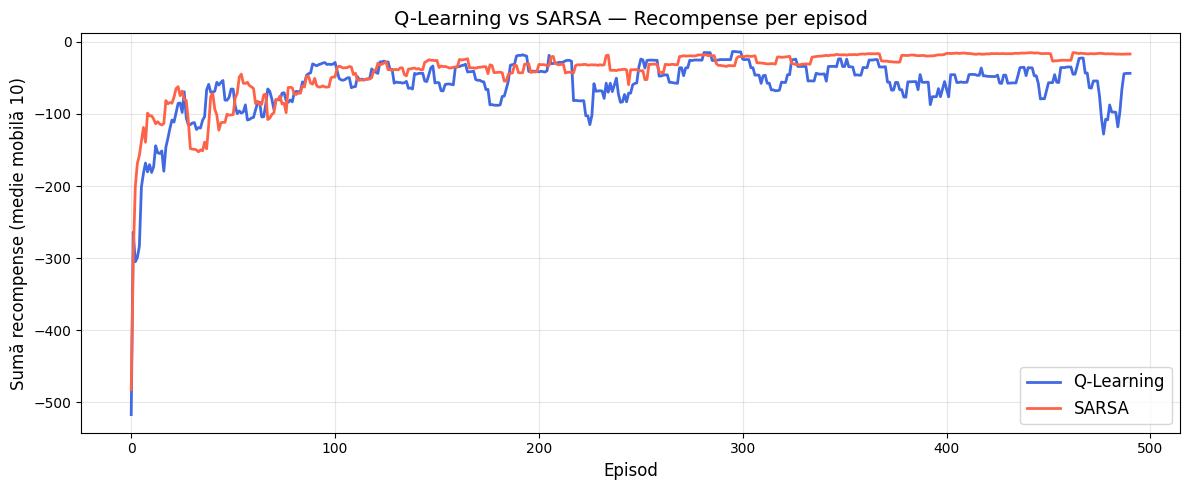

In [48]:
import matplotlib.pyplot as plt

fig_rewards = plot_rewards(rw_ql, rw_sarsa, window=10)
plt.show()

# Se observa ca SARSA are o traiectorie mai dreapta, iar Q-Learning are coborari frecvente si apoi urcari, semn ca desi stie drumul mai scurt, totusi alege sa faca
# anumite ocolisuri pentru a se asigura ca nu va cadea in prapastie

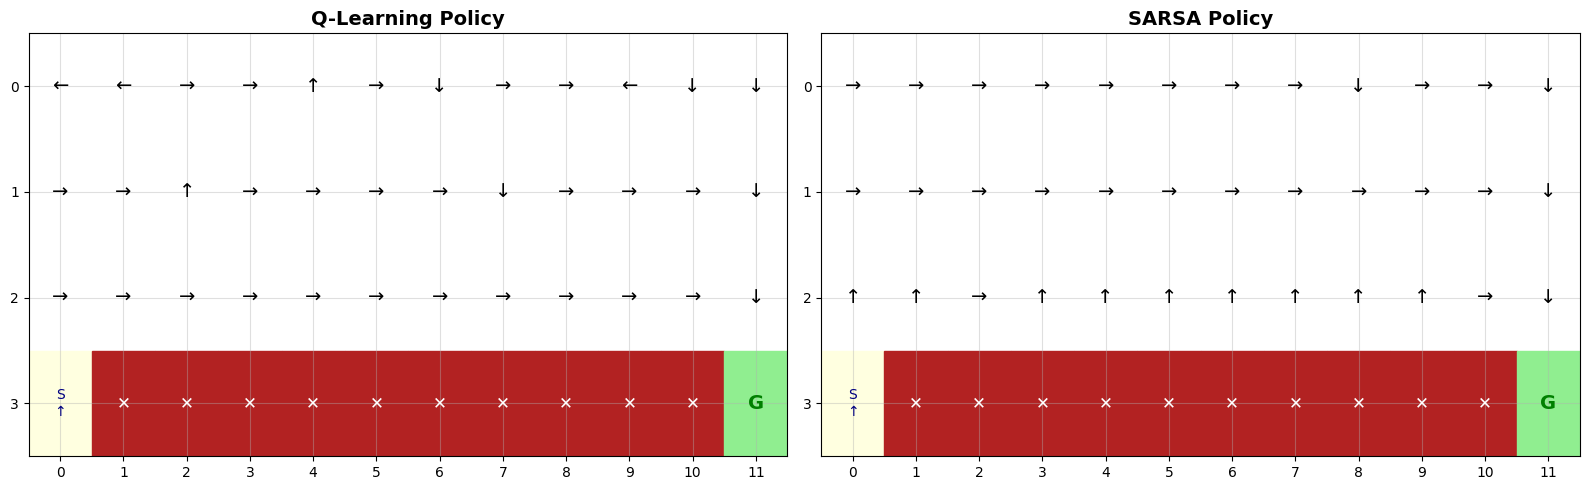

In [49]:
fig_policies = plot_policy(env, Q_ql, Q_sarsa)
plt.show()

In [50]:
steps_ql = greedy_path_length(env, Q_ql)
steps_sarsa = greedy_path_length(env, Q_sarsa)

print(f"Drumul optim găsit de Q-Learning are {steps_ql} pași.")
print(f"Drumul optim găsit de SARSA are {steps_sarsa} pași.")

Drumul optim găsit de Q-Learning are 13 pași.
Drumul optim găsit de SARSA are 15 pași.


In [ ]:
# (a) Care algoritm invata un drum mai scurt? Care obtine recompensa mai mare
#    in timpul antrenarii?
#
#    Q-learning invata drumul mai scurt in politica greedy finala: merge pe
#    marginea de jos a grilei (rândul 3), imediat langa prapastie. Acest drum
#    are doar 11 pasi (de la Start la Goal), minimizand recompensa negativa
#    cumulată. SARSA, in schimb, invata un drum mai sigur prin randul 1 sau 2,
#    care este mai lung (~13-15 pași).
#
#    Paradoxal, SARSA obtine o suma cumulata mai mare in timpul antrenarii,
#    deoarece evita caderea frecventa in prapastie. Cu ε=0.1, agentul exploreaza
#    aleator 10% din timp — daca esti pe marginea prapastiei, o singura miscare
#    aleatorie te penalizează cu -100. SARSA stie ca va face erori de explorare
#    si alege un drum departe de risc. Q-learning, desi converge la o politica
#    greedy mai buna, cade des in prapastie in timpul antrenarii.

In [ ]:
# (b) De ce converg la politici diferite?

#    Diferenta fundamentala consta in constructia tintei TD(suma dintre realitate si ce se crede despre viitor):

#    Q-learning (off-policy):
#        Tinta = r + γ · max_{a'} Q(s', a')
#    Foloseste actiunea OPTIMA din starea urmatoare, indiferent de ce face
#    agentul in realitate. Acest lucru inseamna ca Q-learning evalueaza
#    politica greedy perfecta — ca și cum ε ar fi 0. Astfel, celulele de
#    langa prapastie capata valori Q ridicate, deoarece in imaginarul
#    Q-learning agentul nu va cadea niciodata.

#    SARSA (on-policy):
#        Tinta = r + γ · Q(s', a')   unde a' ~ ε-greedy(Q, s')
#    Foloseste acțiunea EFECTIV aleasa a', care cu probabilitate ε este
#    aleatorie. Cand agentul se afla langa prapastie, a' poate fi o
#    miscare aleatorie care il aruncă in abis (-100). Aceasta penalizare
#    probabilistica se propaga inapoi in valorile Q ale celulelor de margine,
#    scazand atractivitatea drumului scurt. SARSA evaluează politica REALA,
#    cu toate imperfecțiunile ei.

# Pe scurt:
# Q-learning = "ce aș face daca as fi perfect?"
# SARSA = "ce fac de fapt, inclusiv greșelile?"

In [ ]:
# (c) De ce nu exista o contradictie intre (a) și (b)?

#    Nu exista contradictie deoarece cei doi algoritmi optimizeaza obiective
#    diferite. Q-learning converge la politica optima a MDP-ului (fara
#    explorare) — acel drum scurt este intr-adevar optim daca agentul este
#    pur greedy. SARSA converge la politica optima pentru comportamentul ε-
#    greedy — acel drum lung este cel mai bun drum cand stii ca vei face
#    10% miscari aleatoare.

#    Deci Q-learning "castiga" la politica finala (greedy, fara explorare),
#    dar SARSA "castiga" in timpul antrenarii (cand explorarea este activa).
#    Ambii algoritmi fac exact ce sunt proiectati să faca — nu există un
#    "castigator" absolut, depinde de contextul de evaluare.

# Reward shaping

In [63]:
class CliffWalkingEnvShaped(CliffWalkingEnv):
    """
    Penalizare suplimentara pentru celulele din randul 2 (adiacent prapastiei).
    Aceasta face ca Q-learning sa nu mai prefere drumul pe randul 3,
    deoarece chiar si fara explorare, valoarea Q a celulelor de pe randul 2
    scade sub cea a drumului sigur.
    """
    def step(self, action: int):
        s_next, r, done = super().step(action)
        r_next, c_next = self._s_to_rc(s_next)

        # Penalizare pentru randul 2 (adiacent prapastiei)
        if r_next == 2:
            r += -50

        return s_next, r, done

In [60]:
def run_experiment_shaped():
    env_s = CliffWalkingEnvShaped()
    Q_ql_s,    rw_ql_s    = run_q_learning(env_s)
    Q_sarsa_s, rw_sarsa_s = run_sarsa(env_s)
    return env_s, Q_ql_s, Q_sarsa_s, rw_ql_s, rw_sarsa_s

  Lungime drum Q-Learning (shaped) : 15
  Lungime drum SARSA (shaped)      : 17


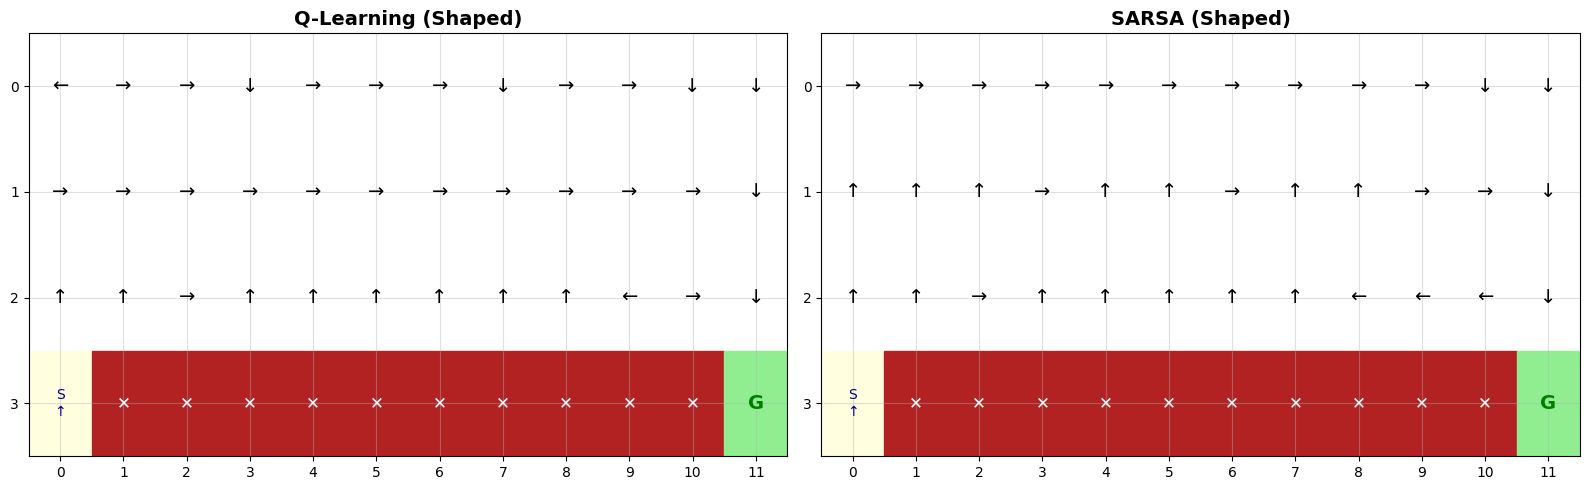

In [62]:
env_s, Q_ql_s, Q_sarsa_s, rw_ql_s, rw_sarsa_s = run_experiment_shaped()
fig3 = plot_policy(env_s, Q_ql_s, Q_sarsa_s, "Q-Learning (Shaped)","SARSA (Shaped)")
fig3.savefig('plot_shaped.png', dpi=150, bbox_inches='tight')

env_s_copy = CliffWalkingEnvShaped()
len_ql_s = greedy_path_length(env_s_copy, Q_ql_s)
len_sarsa_s = greedy_path_length(env_s_copy, Q_sarsa_s)
print(f"  Lungime drum Q-Learning (shaped) : {len_ql_s}")
print(f"  Lungime drum SARSA (shaped)      : {len_sarsa_s}")

In [ ]:
# Modificare: orice celula din randul 3 (cu excepția Goal) primeste o
# penalizare suplimentara de -50 per pas.

# Mecanismul identificat la cerința 3 arata ca algoritmul
# Q-learning prefera drumul scurt pentru ca evalueaza starea (3, c) ca
# sigura. Cu shaping-ul adaugat, valoarea Q a acestor celule scade cu
# ~10 per pas, ceea ce elimina avantajul drumului scurt chiar si pentru
# Q-learning (care nu "vede" riscul de explorare). Ambii algoritmi ajung
# sa prefere randul superior, unde penalizarea per pas este doar -1.

# Esential: shaping-ul modifica valorile Q absolute ale celulelor de
# margine, nu doar perceptia riscului. Astfel, chiar si un agent cu
# ε=0 evita randul 3.

#  ε-scheduling

In [64]:
def run_sarsa_epsilon_decay(env, n_episodes=500, alpha=0.1, gamma=1.0, epsilon_start=0.5, decay=0.99):
    # In experimentele anterioare, ε a fost fix (0.1).
    # Agentul facea greseli (explora) în 10% din timp, de la inceputul pana la sfarsitul celor 500 de episoade.
    # In cadrul Epsilon Decay, la inceput pornim cu o explorare mare (ε = 0.5) ea scade treptat dupa fiecare episod
    # La început: Agentul este foarte curios și face mult haos (explorare 50%).
    # La final: După 500 de episoade, ε devine aproape 0. Agentul devine un profesionist care nu mai face aproape nicio miscare la intamplare.
    # Matematic, practic SARSA se transforma in Q-Learning deoarece cand explorarea dispare, actiunea aleasa de agent va fi intotdeauna cea mai buna actiune

    Q = np.zeros((env.N_STATES, env.N_ACTIONS))
    episode_rewards = []
    epsilon = epsilon_start

    for ep in range(n_episodes):
        s = env.reset()
        a = epsilon_greedy(Q, s, epsilon, env.N_ACTIONS)
        total_reward = 0
        done = False

        while not done:
            s_next, r, done = env.step(a)
            total_reward += r
            a_next = epsilon_greedy(Q, s_next, epsilon, env.N_ACTIONS)

            td_target = r + gamma * Q[s_next, a_next] * (not done)
            Q[s, a] += alpha * (td_target - Q[s, a])

            s = s_next
            a = a_next

        episode_rewards.append(total_reward)
        epsilon = max(1e-4, epsilon * decay)   # ε ≥ 1e-4 pentru stabilitate

    return Q, episode_rewards

  Lungime drum SARSA (ε-decay): 15


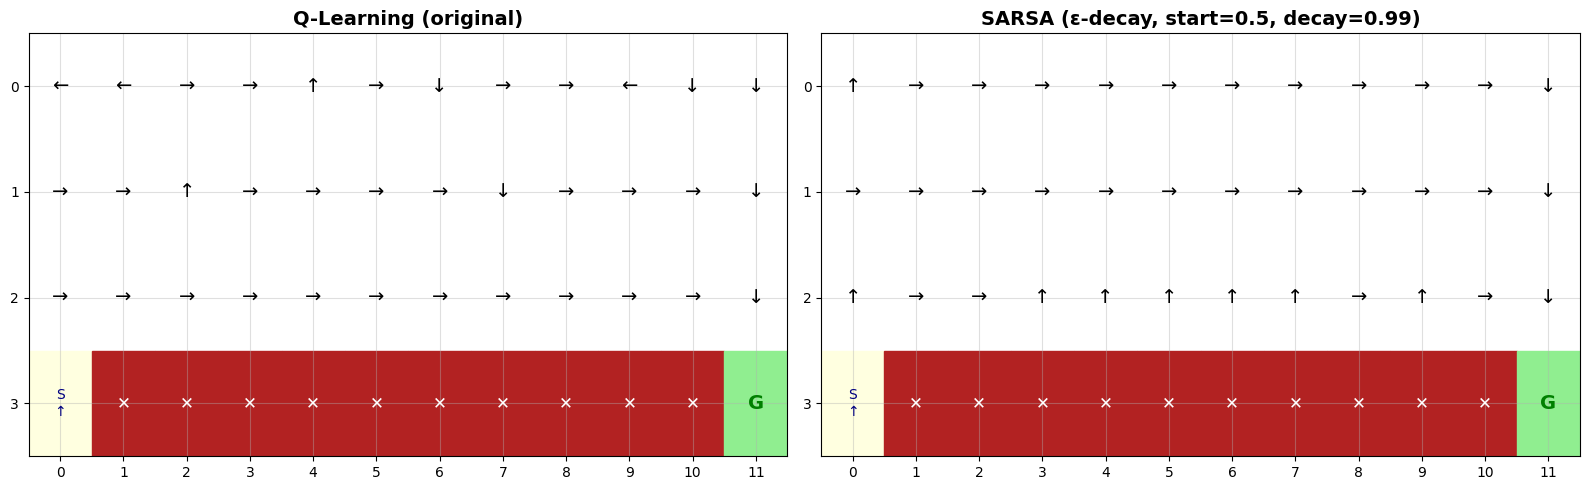

In [65]:
Q_sarsa_decay, rw_sarsa_decay = run_sarsa_epsilon_decay(env, n_episodes=500, alpha=0.1, gamma=1.0, epsilon_start=0.5, decay=0.99)
fig4 = plot_policy(env, Q_ql, Q_sarsa_decay, "Q-Learning (original)", "SARSA (ε-decay, start=0.5, decay=0.99)")
fig4.savefig('plot_epsilon_decay.png', dpi=150, bbox_inches='tight')

env_copy2 = CliffWalkingEnv()
len_sarsa_d = greedy_path_length(env_copy2, Q_sarsa_decay)
print(f"  Lungime drum SARSA (ε-decay): {len_sarsa_d}")

In [66]:
# Schema: ε_t = ε_0 · decay^t, cu ε_0=0.5, decay=0.99.

# Cand ε → 0, politica ε-greedy devine tot mai determinista: actiunea aleasa a' din s' este aproape intotdeauna argmax Q(s',a').

# Tinta SARSA devine: r + γ · Q(s', argmax_{a'} Q(s',a')) = r + γ · max_{a'} Q(s',a')

# Aceasta este identica cu tinta Q-learning! Astfel, la final, SARSA cu ε→0 convergge la aceeasi solutie ca Q-learning, preferand drumul scurt.
# Această echivalenta demonstreaza ca diferenta dintre algoritmi nu este structurala, ci provine din politica de explorare activa.

# Reflectie teoretica

In [ ]:
# Q1. Ce se întâmplă cu ε=0 de la start?

    # Q-learning cu ε=0: agentul este pur greedy de la start. Cu Q inițializat la 0, toate actiunile par echivalente si agentul o alege pe prima.
    # Dacă nu exploreaza, va ramane blocat pe aceeasi traiectorie, fara sa descopere vreodata Goal-ul, deci nu va converge la politica optimă.

    # SARSA cu ε=0: comportament identic — fara explorare, agentul nu poate explora mediul. SARSA on-policy fara explorare este chiar mai fragil:
    # dacă prima traiectorie nu ajunge la Goal, valorile Q raman 0 peste tot si nu exista mecanism de iesire din aceasta situatie.
    # ε>0 este esential pentru convergenta ambilor algoritmi.

# Q2. Cum se schimba preferintele cu γ < 1 (ex: γ=0.9)?

    # Cu γ < 1, recompensele viitoare valorează mai putin. Drumul lung are mai multi pasi, iar drumul scurt (11 pasi) are un avantaj fata de drumul lung (13-15 pasi),
    # deoarece minimizeaza numarul de discount-uri aplicate.

    # Efectul: Ambii algoritmi vor tinde spre drumul scurt mai mult decat cu γ = 1. Cu γ suficient de mic (ex: 0.5), chiar si SARSA poate prefera drumul scurt,
    # deoarece recompensa -100 de cadere in prăpastie (departe, cu explorare) valoreaza suficient de mult.

# Q3. Exemplu real in care ati prefera SARSA fata de Q-learning:

    # Robotica medicala (ex: robot chirurgical de asistenta).
    # Un robot care insoteste un chirurg trebuie să invețe miscari precise. In antrenare, robotul va explora (ε>0) si va face miscari suboptimale.
    # Q-learning ar ignora riscul miscarilor aleatorii in zone critice (langa organe vitale) si ar putea converge la o politica agresiva care in realitate
    # cauzeaza accidente. SARSA, evaluand comportamentul REAL (cu explorare), va fi mai conservator si va evita zonele cu risc ridicat chiar daca aceasta inseamna
    # un drum mai lung. Siguranța in timpul antrenarii primeaza fata de optimalitatea teoretica.

In [ ]:
# Tabelul Q
# Inițializarea cu 0 este pesimista fata de recompense pozitive, dar neutra fata de recompensele negative din joc (care sunt −1, −100).
# Practic, agentul porneste fara nicio prejudecata si valorile scad pe masura ce descopera penalizările.
# Ce s-ar intampla cu valori mari pozitive? Agentul ar fi "dezamăgit" de fiecare recompensă reală (−1 < +10),
# ceea ce l-ar forta sa exploreze mai agresiv la inceput — poate util, dar poate destabiliza convergenta.
# Ce s-ar intampla cu valori mari negative? Agentul ar considera orice miscare mai buna decat se astepta, favorizand
# exploatarea prematura a primului drum gasit, indiferent de calitate.



# Intr-un mediu stochastic, step(action) ar returna un s' diferit fata de cel asteptat.
# Consecintele:
# Q-Learning: Mai robust teoretic, deoarece max Q(s', ·) estimează valoarea asteptata over toate rezultatele posibile — dar convergenaa este mai lentă.
# SARSA: Mai afectat, deoarece Q(s', a') estimează valoarea unui singur s'



# Cum s-ar scala abordarea la un mediu cu 10^6 stari?
# Problema: Un Q-table cu 10^6 stări × N actiuni ar necesita zeci de MB de memorie si milioane de episoade pentru a umple toate celulele — imposibil practic.
# Solutia: Function approximation — in loc de tabel, folosim o funcție (ex: rețea neuronală) care aproximează Q(s, a; θ) parametrizată prin θ: